# Model Penilaian Kredit Nasabah (Credit Score Classification)

**Studi Kasus:** Sebuah institusi keuangan membutuhkan cara yang sistematis dan berbasis data untuk menilai performa kredit setiap nasabah. Setiap nasabah perlu dikelompokkan ke dalam salah satu dari tiga kategori risiko kredit, yaitu **Poor**, **Standard**, atau **Good**. Notebook ini berisi proses eksplorasi data, pembersihan data, pra-pemrosesan, eksperimen pemodelan, evaluasi, dan penyimpanan model akhir yang akan digunakan pada tahap deployment.

Notebook ini disusun mengikuti alur kerja standar seorang data scientist, yaitu:

1. Pemahaman dan eksplorasi data (EDA)
2. Pembersihan data dan pra-pemrosesan
3. Pembagian data latih dan data uji
4. Eksperimen beberapa algoritma machine learning
5. Pemilihan dan penyetelan model terbaik
6. Evaluasi model pada data uji
7. Penyimpanan model untuk kebutuhan deployment
8. Ringkasan penjelasan teknis (fitur, pra-pemrosesan, model, metrik evaluasi, dan eksperimen)

**Catatan revisi (v3):** Selain perbaikan arsitektural pada versi sebelumnya (pembersihan data dibungkus sebagai custom transformer, validasi silang berbasis `StratifiedGroupKFold`), versi ini menambahkan: (1) `RobustScaler` menggantikan `StandardScaler` untuk fitur numerik yang condong (skewed), (2) algoritma `XGBoost` sebagai kandidat model tambahan, (3) ruang pencarian hyperparameter yang lebih luas, (4) eksperimen penanganan ketidakseimbangan kelas menggunakan SMOTE, dan (5) penyetelan ambang batas probabilitas (threshold tuning) untuk kelas minoritas `Good`. Penjelasan lengkap mengenai perubahan ini, termasuk satu poin evaluasi sebelumnya yang klaimnya tidak sesuai dengan kode aktual, ada di bagian akhir notebook.


In [2]:
# 1. Import Library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import pickle

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Memuat Data

Dataset berisi data bulanan setiap nasabah, mencakup informasi demografis, riwayat pinjaman, perilaku pembayaran, dan kondisi keuangan. Kolom target yang akan diprediksi adalah `Credit_Score`.

In [3]:
df_raw = pd.read_csv("data_D.csv", index_col=0)
print("Ukuran data:", df_raw.shape)
df_raw.head()

Ukuran data: (25000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,8,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,9,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,7,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,8,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,3,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22471 non-null  object 
 4   Age                       25000 non-null  object 
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  object 
 8   Monthly_Inhand_Salary     21173 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  
 12  Num_of_Loan               25000 non-null  object 
 13  Type_of_Loan              22120 non-null  object 
 14  Delay_from_

## 2. Eksplorasi Data (EDA)

Tahap ini bertujuan untuk memahami karakteristik data secara menyeluruh sebelum dilakukan pemodelan, mencakup struktur data, kualitas data, distribusi target, distribusi fitur, dan hubungan antar fitur.

### 2.1 Karakteristik Struktural Data

Hal pertama yang perlu diperhatikan adalah bahwa data ini bersifat **panel atau longitudinal**, yaitu satu nasabah (`Customer_ID`) dapat memiliki lebih dari satu baris data yang mewakili bulan pengamatan yang berbeda (`Month`). Karakteristik ini penting karena memengaruhi cara pembagian data latih dan data uji, agar tidak terjadi kebocoran data (data leakage) akibat satu nasabah yang sama muncul baik di data latih maupun data uji.

In [5]:
n_rows = df_raw.shape[0]
n_customers = df_raw["Customer_ID"].nunique()
print(f"Jumlah baris data : {n_rows}")
print(f"Jumlah nasabah unik : {n_customers}")
print(f"Rata-rata jumlah observasi per nasabah : {n_rows / n_customers:.2f}")
df_raw["Customer_ID"].value_counts().describe()

Jumlah baris data : 25000
Jumlah nasabah unik : 11199
Rata-rata jumlah observasi per nasabah : 2.23


count    11199.000000
mean         2.232342
std          1.086517
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: count, dtype: float64

### 2.2 Kualitas Data: Nilai Hilang dan Nilai Tidak Valid

Pemeriksaan tipe data menunjukkan bahwa banyak kolom numerik (misalnya `Age`, `Annual_Income`, `Num_of_Loan`, `Outstanding_Debt`, `Amount_invested_monthly`, dan `Monthly_Balance`) tersimpan sebagai teks (object), bukan angka. Hal ini terjadi karena adanya karakter tidak valid yang tercampur di dalam nilai numerik, misalnya garis bawah ("_") di akhir angka, atau nilai sentinel rusak seperti "__10000__". Selain itu terdapat pula kolom kategorikal dengan nilai placeholder yang tidak bermakna, misalnya "_______" pada `Occupation`, "_" pada `Credit_Mix`, dan "!@9#%8" pada `Payment_Behaviour`.

In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
Monthly_Inhand_Salary,3827,15.31
Type_of_Loan,2880,11.52
Name,2529,10.12
Credit_History_Age,2249,9.00
Num_of_Delayed_Payment,1744,6.98
Amount_invested_monthly,1121,4.48
Num_Credit_Inquiries,497,1.99
Monthly_Balance,309,1.24


In [7]:
# Contoh nilai-nilai bermasalah pada kolom yang seharusnya numerik
suspect_cols = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
                 "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]
for c in suspect_cols:
    print(f"{c:28s}: dtype={str(df_raw[c].dtype):10s} contoh nilai unik -> {df_raw[c].astype(str).unique()[:6]}")

Age                         : dtype=object     contoh nilai unik -> ['32' '39' '45' '18' '28' '30']
Annual_Income               : dtype=object     contoh nilai unik -> ['56125.5' '62148.0' '88380.16' '7821.24' '107871.9' '79950.34']
Num_of_Loan                 : dtype=object     contoh nilai unik -> ['2' '5' '3' '6' '4' '9']
Num_of_Delayed_Payment      : dtype=object     contoh nilai unik -> ['14' '25' '19' '17' '20' '3']
Changed_Credit_Limit        : dtype=object     contoh nilai unik -> ['17.89' '_' '8.7' '19.34' '11.27' '2.27']
Outstanding_Debt            : dtype=object     contoh nilai unik -> ['370.22' '2373.61' '124.29' '2924.76' '1005.83' '515.89']
Amount_invested_monthly     : dtype=object     contoh nilai unik -> ['182.06551022025016' '195.3722153038279' '180.79874191787297'
 '39.93770264234067' '73.48570828760295' '86.85770355819382']
Monthly_Balance             : dtype=object     contoh nilai unik -> ['473.62413320457887' '300.6789235920986' '686.5788927990964'
 '267.2113738

In [8]:
print("Nilai unik Occupation     :", sorted(df_raw['Occupation'].unique())[:5], "...")
print("Nilai unik Credit_Mix      :", df_raw['Credit_Mix'].unique())
print("Nilai unik Payment_Behaviour:", df_raw['Payment_Behaviour'].unique())
print("Nilai unik Payment_of_Min_Amount:", df_raw['Payment_of_Min_Amount'].unique())

Nilai unik Occupation     : ['Accountant', 'Architect', 'Developer', 'Doctor', 'Engineer'] ...
Nilai unik Credit_Mix      : ['Standard' 'Bad' '_' 'Good']
Nilai unik Payment_Behaviour: ['High_spent_Medium_value_payments' 'High_spent_Small_value_payments'
 'Low_spent_Medium_value_payments' 'High_spent_Large_value_payments'
 'Low_spent_Large_value_payments' '!@9#%8'
 'Low_spent_Small_value_payments']
Nilai unik Payment_of_Min_Amount: ['Yes' 'No' 'NM']


**Temuan:** Sebagian besar nilai hilang dan nilai rusak ini bukan disebabkan oleh proses pengambilan data yang acak, melainkan kesalahan pencatatan/encoding (corrupted text). Karena data bersifat panel, nilai-nilai ini berpotensi diisi ulang menggunakan informasi dari baris lain milik nasabah yang sama, yang akan dilakukan pada tahap pembersihan data.

### 2.3 Distribusi Variabel Target

Variabel target `Credit_Score` memiliki tiga kelas, yaitu Poor, Standard, dan Good. Distribusi kelas perlu diperiksa untuk mengetahui apakah data mengalami ketidakseimbangan kelas (class imbalance), karena hal ini akan memengaruhi pemilihan metrik evaluasi dan strategi pemodelan.

              jumlah  persentase
Credit_Score                    
Standard       13305       53.22
Poor            7231       28.92
Good            4464       17.86


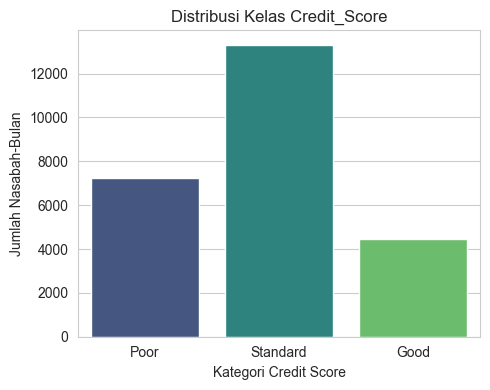

In [9]:
target_counts = df_raw["Credit_Score"].value_counts()
target_pct = (target_counts / len(df_raw) * 100).round(2)
print(pd.DataFrame({"jumlah": target_counts, "persentase": target_pct}))

plt.figure(figsize=(5,4))
order = ["Poor", "Standard", "Good"]
sns.countplot(data=df_raw, x="Credit_Score", order=order, palette="viridis")
plt.title("Distribusi Kelas Credit_Score")
plt.xlabel("Kategori Credit Score")
plt.ylabel("Jumlah Nasabah-Bulan")
plt.tight_layout()
plt.show()

**Temuan:** Kelas `Standard` mendominasi (sekitar 53%), diikuti `Poor` (sekitar 29%), dan `Good` paling sedikit (sekitar 18%). Data tergolong tidak seimbang secara moderat sehingga metrik evaluasi seperti akurasi saja tidak cukup representatif. Metrik berbasis precision, recall, dan F1 (terutama yang dirata-ratakan secara macro) lebih tepat digunakan, dan beberapa model akan menggunakan pembobotan kelas (`class_weight="balanced"`).

### 2.4 Distribusi Fitur Numerik dan Deteksi Anomali

Sebelum dibersihkan, beberapa kolom numerik (yang masih bertipe teks) terlebih dahulu dikonversi sementara untuk keperluan pemeriksaan rentang nilai (range check), guna mendeteksi nilai-nilai yang secara teori tidak mungkin terjadi (misalnya usia negatif, jumlah rekening bank ribuan, atau suku bunga ribuan persen).

In [10]:
def to_numeric_clean(series):
    # Membersihkan karakter non-numerik (mis. garis bawah) lalu mengonversi ke tipe numerik
    return pd.to_numeric(
        series.astype(str).str.replace("_", "", regex=False).str.strip(),
        errors="coerce"
    )

check_cols = ["Age", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
              "Num_of_Loan", "Num_Credit_Inquiries", "Total_EMI_per_month",
              "Amount_invested_monthly", "Delay_from_due_date"]

check_df = pd.DataFrame({c: to_numeric_clean(df_raw[c]) for c in check_cols})
check_df.describe().T[["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
Age,-500.0,25.000000,33.000000,42.000000,8669.0
Num_Bank_Accounts,-1.0,4.000000,6.000000,8.000000,1794.0
Num_Credit_Card,0.0,4.000000,5.000000,7.000000,1499.0
Interest_Rate,1.0,8.000000,13.000000,20.000000,5789.0
Num_of_Loan,-100.0,1.000000,3.000000,5.000000,1485.0
Num_Credit_Inquiries,0.0,3.000000,6.000000,9.000000,2553.0
Total_EMI_per_month,0.0,29.912485,68.781136,160.180388,82122.0
Amount_invested_monthly,0.0,73.887772,133.934709,263.605480,10000.0
Delay_from_due_date,-5.0,10.000000,18.000000,28.000000,67.0


**Temuan:** Beberapa kolom memiliki nilai ekstrem yang tidak masuk akal secara domain, misalnya usia (`Age`) bernilai negatif atau ribuan tahun, jumlah rekening bank (`Num_Bank_Accounts`) dan kartu kredit (`Num_Credit_Card`) bernilai ratusan hingga ribuan, serta suku bunga (`Interest_Rate`) bernilai ribuan persen. Nilai-nilai ini bukan variasi data yang wajar, melainkan kesalahan input/pencatatan, sehingga akan ditangani sebagai nilai tidak valid pada tahap pembersihan data (bukan dianggap sebagai outlier alami yang masih layak dipertahankan).

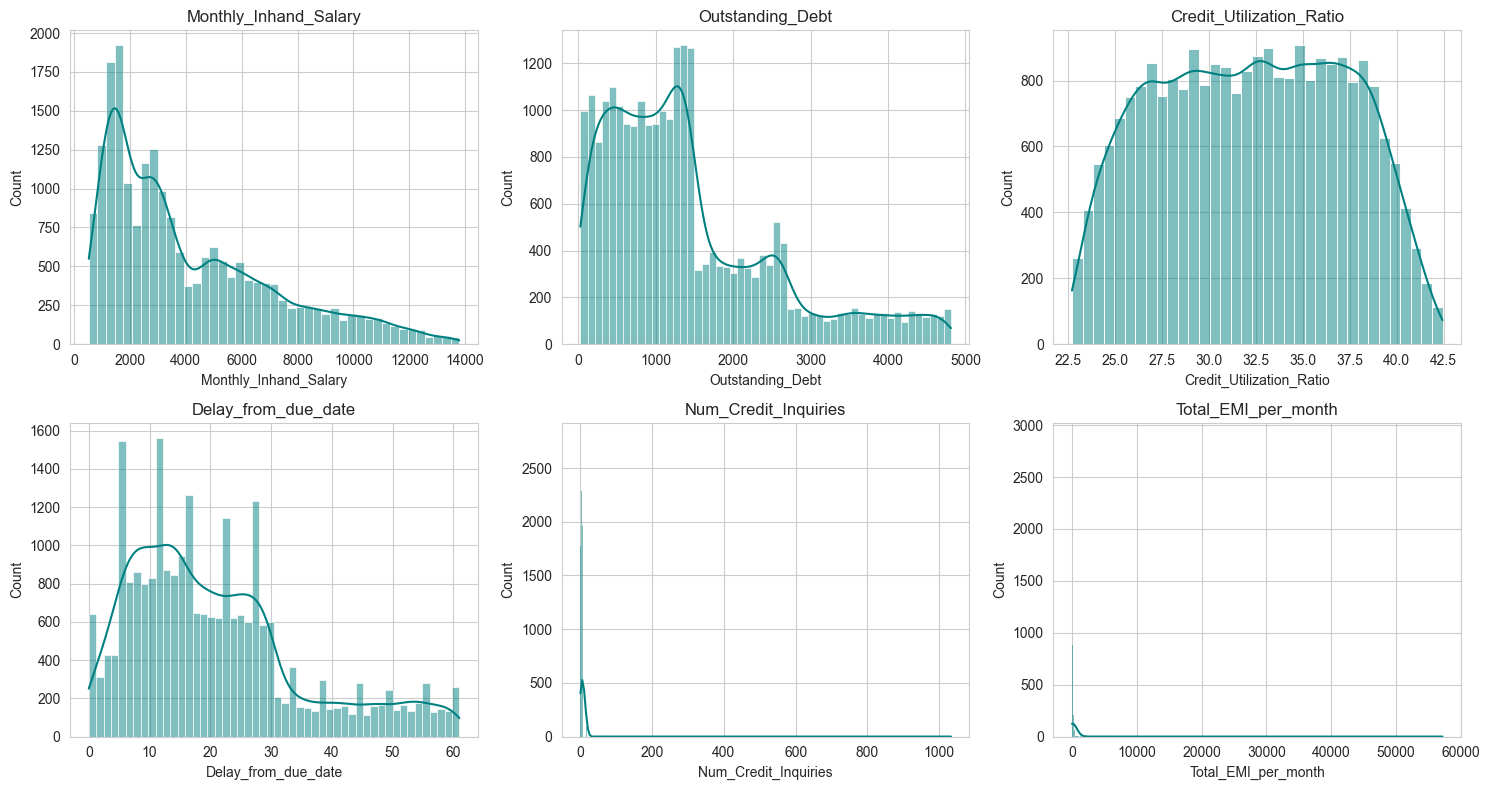

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = ["Monthly_Inhand_Salary", "Outstanding_Debt", "Credit_Utilization_Ratio",
             "Delay_from_due_date", "Num_Credit_Inquiries", "Total_EMI_per_month"]
for ax, col in zip(axes.flatten(), plot_cols):
    data_plot = pd.to_numeric(df_raw[col], errors="coerce")
    # batasi persentil 1-99 hanya untuk visualisasi agar bentuk distribusi inti terlihat jelas
    lo, hi = data_plot.quantile([0.01, 0.99])
    sns.histplot(data_plot[(data_plot >= lo) & (data_plot <= hi)], kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.5 Eksplorasi Fitur Kategorikal terhadap Target

Untuk memahami hubungan awal antara fitur kategorikal dengan target, beberapa fitur kategorikal yang relevan secara domain (`Credit_Mix` dan `Payment_of_Min_Amount`) diperiksa proporsinya terhadap kategori `Credit_Score`.

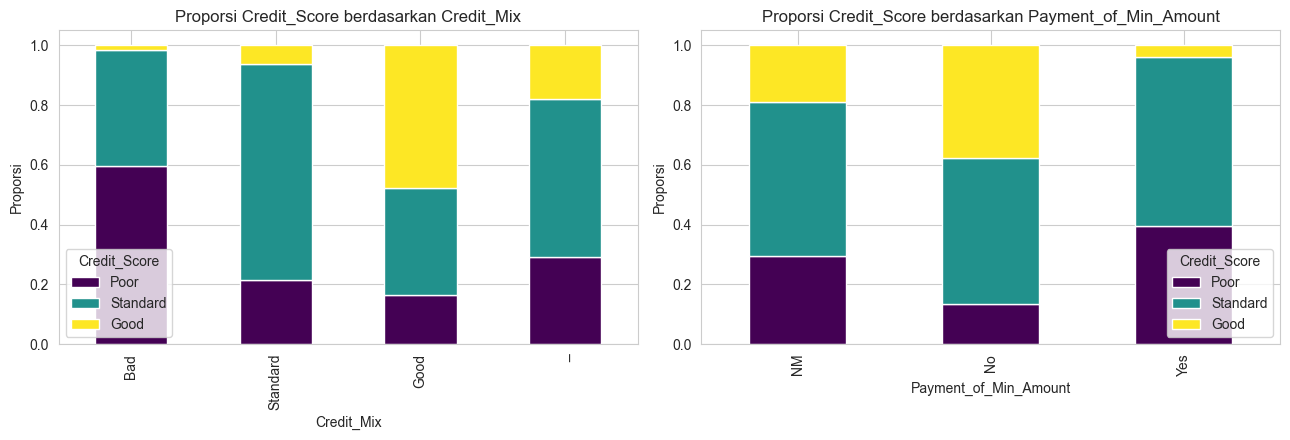

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ct1 = pd.crosstab(df_raw["Credit_Mix"], df_raw["Credit_Score"], normalize="index")
ct1 = ct1.reindex(["Bad", "Standard", "Good", "_"])
ct1[order].plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Proporsi Credit_Score berdasarkan Credit_Mix")
axes[0].set_ylabel("Proporsi")
axes[0].legend(title="Credit_Score")

ct2 = pd.crosstab(df_raw["Payment_of_Min_Amount"], df_raw["Credit_Score"], normalize="index")
ct2[order].plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Proporsi Credit_Score berdasarkan Payment_of_Min_Amount")
axes[1].set_ylabel("Proporsi")
axes[1].legend(title="Credit_Score")

plt.tight_layout()
plt.show()

**Temuan:** Nasabah dengan `Credit_Mix` bernilai "Bad" cenderung memiliki proporsi `Credit_Score` "Poor" yang jauh lebih tinggi dibandingkan nasabah dengan `Credit_Mix` "Good". Demikian pula, nasabah yang hanya membayar jumlah minimum (`Payment_of_Min_Amount` = "Yes") cenderung memiliki proporsi `Credit_Score` "Poor" yang lebih besar. Kedua fitur ini menunjukkan hubungan yang kuat secara intuitif dengan target dan diperkirakan akan menjadi fitur penting dalam model.

### 2.6 Korelasi Antar Fitur Numerik

Pemeriksaan korelasi membantu mengidentifikasi potensi multikolinearitas serta fitur yang berpotensi memiliki hubungan linear dengan target setelah target diberi kode urut (ordinal encoding sementara, hanya untuk eksplorasi).

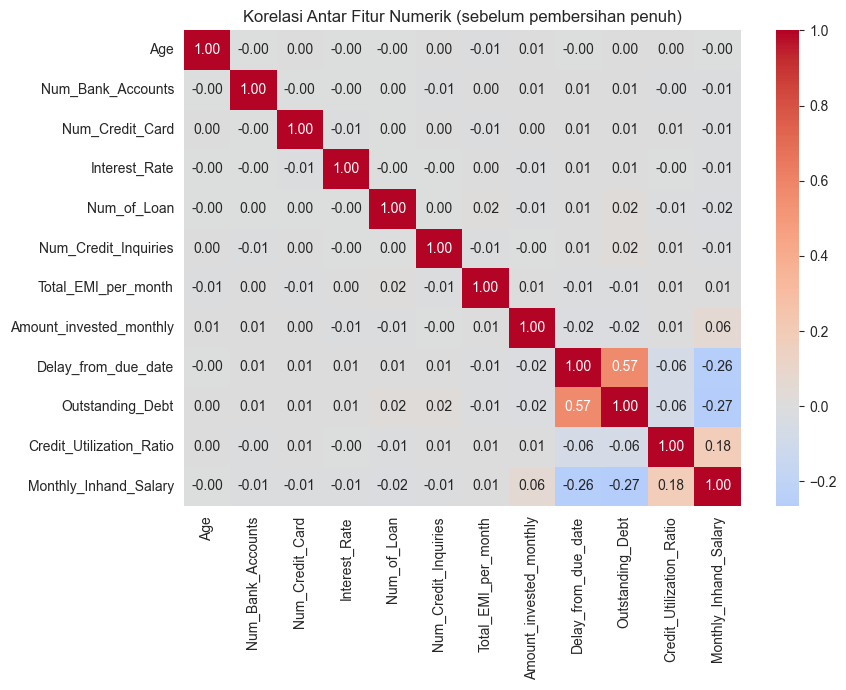

In [13]:
numeric_for_corr = check_df.copy()
numeric_for_corr["Outstanding_Debt"] = pd.to_numeric(df_raw["Outstanding_Debt"].astype(str).str.replace("_","",regex=False), errors="coerce")
numeric_for_corr["Credit_Utilization_Ratio"] = df_raw["Credit_Utilization_Ratio"]
numeric_for_corr["Monthly_Inhand_Salary"] = df_raw["Monthly_Inhand_Salary"]

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Antar Fitur Numerik (sebelum pembersihan penuh)")
plt.tight_layout()
plt.show()

**Temuan:** Tidak terdapat pasangan fitur numerik dengan korelasi yang sangat tinggi (mendekati 1), sehingga risiko multikolinearitas ekstrem relatif rendah dan seluruh fitur numerik tersebut layak dipertahankan untuk pemodelan.

### 2.7 Ringkasan Temuan EDA

1. Data bersifat panel (satu nasabah memiliki beberapa baris observasi bulanan), sehingga pembagian data latih/uji harus dilakukan pada level nasabah, bukan pada level baris.
2. Banyak kolom numerik tersimpan sebagai teks akibat karakter sampah (garis bawah, simbol acak), sehingga perlu dikonversi ke tipe numerik yang benar.
3. Beberapa kolom numerik memiliki nilai yang secara domain tidak valid (negatif, atau jauh melebihi batas wajar), bukan outlier alami, sehingga perlu ditangani sebagai data rusak (invalid value), bukan sekadar dibiarkan.
4. Beberapa kolom kategorikal memiliki nilai placeholder yang merepresentasikan data hilang secara tersamar.
5. Target tidak seimbang secara moderat, sehingga metrik evaluasi berbasis F1-macro lebih sesuai dibandingkan akurasi semata.
6. `Credit_Mix` dan `Payment_of_Min_Amount` menunjukkan hubungan kuat dengan target sehingga berpotensi menjadi fitur penting.


## 3. Pembersihan Data dan Pra-Pemrosesan

Berdasarkan temuan EDA, tahap pembersihan data perlu menangani: (1) kolom numerik yang tersimpan sebagai teks akibat karakter sampah, (2) nilai yang secara domain tidak valid, (3) nilai placeholder pada kolom kategorikal, (4) format teks pada `Credit_History_Age`, dan (5) nilai hilang.

Logika pembersihan ini **tidak dijalankan secara manual sekali pakai di atas DataFrame**. Sebagai gantinya, seluruh logika dibungkus ke dalam satu *custom transformer* scikit-learn (`CreditDataCleaner`) yang menjadi langkah pertama di dalam `Pipeline`. Alasannya bersifat teknis sekaligus praktis untuk kebutuhan deployment:

- Apabila pembersihan dilakukan terpisah di luar `Pipeline`, logika tersebut harus ditulis ulang secara identik pada skrip inferencing saat deployment. Duplikasi ini berisiko membuat hasil training dan hasil inferencing tidak konsisten apabila salah satu salinan kode diubah tanpa mengubah yang lain.
- Dengan membungkusnya sebagai transformer, satu objek `Pipeline` yang disimpan (`.pkl`) sudah mencakup pembersihan, imputasi, penskalaan, encoding, dan model klasifikasi sekaligus. Skrip inferencing saat deployment cukup memanggil `pipeline.predict(data_mentah)` dengan data mentah dalam format sama seperti `data_D.csv`, tanpa perlu menulis ulang logika pembersihan apa pun.

Sel berikut mendefinisikan fungsi-fungsi pembantu (helper function) yang akan dipakai di dalam transformer, sekaligus didemonstrasikan satu kali pada salinan data untuk verifikasi bahwa logikanya benar sebelum dibungkus menjadi transformer.

In [14]:
def to_numeric_clean(series):
    # Membersihkan karakter non-numerik (mis. garis bawah) lalu mengonversi ke tipe numerik
    return pd.to_numeric(
        series.astype(str).str.replace("_", "", regex=False).str.strip(),
        errors="coerce"
    )

def parse_credit_history_age_vec(series):
    # Versi tervektorisasi (tanpa apply per baris) dari "X Years and Y Months" -> total bulan
    extracted = series.astype(str).str.extract(r"(\d+)\s*Years?\s*and\s*(\d+)\s*Months?")
    years = pd.to_numeric(extracted[0], errors="coerce")
    months = pd.to_numeric(extracted[1], errors="coerce")
    return years * 12 + months

def count_loan_types_vec(series):
    # Versi tervektorisasi (tanpa apply per baris) untuk menghitung jumlah jenis pinjaman
    s = series.astype(str)
    is_specified = series.notna() & (s.str.strip().str.lower() != "not specified")
    counts = s.str.count(",") + 1
    return pd.Series(np.where(is_specified, counts, 0), index=series.index)

def mode_or_nan(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

VALID_RANGES = {
    "Age": (14, 100),
    "Annual_Income": (0, 2_000_000),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 40),
    "Num_of_Loan": (0, 15),
    "Num_of_Delayed_Payment": (0, 60),
    "Num_Credit_Inquiries": (0, 50),
    "Delay_from_due_date": (-10, 100),
    "Total_EMI_per_month": (0, 10000),
    "Amount_invested_monthly": (0, 9999),   # nilai 10000 adalah sentinel rusak ("__10000__")
}

NUMERIC_TEXT_COLS = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
                      "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly",
                      "Monthly_Balance"]

NUMERIC_IMPUTE_COLS = ["Age","Annual_Income","Monthly_Inhand_Salary","Num_Bank_Accounts",
                       "Num_Credit_Card","Interest_Rate","Num_of_Loan","Num_of_Delayed_Payment",
                       "Changed_Credit_Limit","Num_Credit_Inquiries","Outstanding_Debt",
                       "Total_EMI_per_month","Amount_invested_monthly","Monthly_Balance",
                       "Credit_History_Age_Months"]

CATEGORICAL_IMPUTE_COLS = ["Occupation","Credit_Mix","Payment_Behaviour"]

ID_COLS = ["ID", "Customer_ID", "SSN", "Name", "Month"]

NUMERIC_FEATURES = NUMERIC_IMPUTE_COLS + ["Num_Loan_Types", "Credit_Utilization_Ratio"]
CATEGORICAL_FEATURES = CATEGORICAL_IMPUTE_COLS + ["Payment_of_Min_Amount"]

# Verifikasi cepat: terapkan satu kali pada salinan data untuk memastikan logika benar
_demo = df_raw.copy()
for c in NUMERIC_TEXT_COLS:
    _demo[c] = to_numeric_clean(_demo[c])
for col, (lo, hi) in VALID_RANGES.items():
    _demo.loc[~_demo[col].between(lo, hi), col] = np.nan
_demo["Occupation"] = _demo["Occupation"].replace("_______", np.nan)
_demo["Credit_Mix"] = _demo["Credit_Mix"].replace("_", np.nan)
_demo["Payment_Behaviour"] = _demo["Payment_Behaviour"].replace("!@9#%8", np.nan)
_demo["Credit_History_Age_Months"] = parse_credit_history_age_vec(_demo["Credit_History_Age"])
_demo["Num_Loan_Types"] = count_loan_types_vec(_demo["Type_of_Loan"])

print("Verifikasi pembersihan pada salinan data (sebelum dibungkus ke transformer):")
print(_demo[NUMERIC_TEXT_COLS + ["Credit_History_Age_Months", "Num_Loan_Types"]].describe().T[["min","50%","max"]])
del _demo

Verifikasi pembersihan pada salinan data (sebelum dibungkus ke transformer):
                                    min           50%           max
Age                        1.400000e+01     33.000000  1.000000e+02
Annual_Income              7.005930e+03  36938.820000  1.888622e+06
Num_of_Loan                0.000000e+00      3.000000  9.000000e+00
Num_of_Delayed_Payment     0.000000e+00     14.000000  5.200000e+01
Changed_Credit_Limit      -6.440000e+00      9.380000  3.697000e+01
Outstanding_Debt           2.300000e-01   1158.960000  4.998070e+03
Amount_invested_monthly    0.000000e+00    127.276627  1.961219e+03
Monthly_Balance           -3.333333e+26    338.053724  1.602041e+03
Credit_History_Age_Months  2.000000e+00    220.000000  4.040000e+02
Num_Loan_Types             0.000000e+00      3.000000  9.000000e+00


### 3.1 Custom Transformer: `CreditDataCleaner`

Transformer berikut mengimplementasikan seluruh logika pembersihan dan imputasi di atas sebagai satu komponen scikit-learn (`fit`/`transform`) yang dapat ditempatkan sebagai langkah pertama dalam `Pipeline`.

Mekanisme imputasi dirancang agar konsisten antara training dan inferencing:

- Pada `fit` (hanya dijalankan pada data latih), transformer mempelajari dan menyimpan median/modus **global** dari data latih untuk setiap kolom.
- Pada `transform`, jika input membawa `Customer_ID` dan terdapat lebih dari satu baris untuk nasabah yang sama dalam batch tersebut (skenario penilaian ulang/batch scoring), nilai hilang diisi terlebih dahulu menggunakan median/modus nasabah itu sendiri dalam batch yang sedang diproses. Sisa nilai hilang (termasuk kasus nasabah baru dengan satu baris data saja, yang merupakan skenario realistis saat inferencing satu nasabah baru) diisi menggunakan median/modus global yang sudah dipelajari saat `fit`.

Dengan demikian transformer ini aman digunakan baik untuk training, untuk evaluasi batch nasabah lama, maupun untuk inferencing satu nasabah baru yang belum pernah terlihat sama sekali.

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class CreditDataCleaner(BaseEstimator, TransformerMixin):
    # Membersihkan data mentah Credit_Score (format data_D.csv) dan mengisi nilai hilang,
    # lalu mengembalikan DataFrame siap pakai untuk ColumnTransformer di tahap selanjutnya.

    def __init__(self):
        pass

    def _basic_clean(self, X):
        df = X.copy()
        for c in NUMERIC_TEXT_COLS:
            df[c] = to_numeric_clean(df[c])
        for col, (lo, hi) in VALID_RANGES.items():
            df.loc[~df[col].between(lo, hi), col] = np.nan
        df["Occupation"] = df["Occupation"].replace("_______", np.nan)
        df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
        df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan)
        df["Credit_History_Age_Months"] = parse_credit_history_age_vec(df["Credit_History_Age"])
        df["Num_Loan_Types"] = count_loan_types_vec(df["Type_of_Loan"])
        df.drop(columns=["Credit_History_Age", "Type_of_Loan"], inplace=True)
        return df

    def fit(self, X, y=None):
        df = self._basic_clean(X)
        self.global_medians_ = {c: df[c].median() for c in NUMERIC_IMPUTE_COLS}
        self.global_modes_ = {c: mode_or_nan(df[c]) for c in CATEGORICAL_IMPUTE_COLS}
        self.feature_columns_ = NUMERIC_FEATURES + CATEGORICAL_FEATURES
        return self

    def transform(self, X):
        df = self._basic_clean(X)
        has_customer = "Customer_ID" in df.columns

        for c in NUMERIC_IMPUTE_COLS:
            if has_customer:
                grp_median = df.groupby("Customer_ID")[c].transform("median")
                df[c] = df[c].fillna(grp_median)
            df[c] = df[c].fillna(self.global_medians_[c])

        for c in CATEGORICAL_IMPUTE_COLS:
            if has_customer:
                df[c] = df.groupby("Customer_ID")[c].transform(lambda s: s.fillna(mode_or_nan(s)))
            df[c] = df[c].fillna(self.global_modes_[c])

        drop_cols = [c for c in ID_COLS if c in df.columns]
        df = df.drop(columns=drop_cols)
        return df[self.feature_columns_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_columns_)


### 3.2 Verifikasi Perilaku Imputasi untuk Nasabah Baru (Single-Row Inference)

Perlu dipastikan bahwa `CreditDataCleaner` berperilaku benar pada skenario deployment yang realistis, yaitu ketika hanya ada **satu baris data** untuk satu nasabah baru yang sama sekali tidak memiliki riwayat bulan lain (berbeda dengan data training yang bersifat panel). Pada skenario ini, imputasi berbasis grup (`groupby("Customer_ID")`) terhadap grup berisi satu baris dengan nilai hilang akan tetap menghasilkan nilai hilang (karena tidak ada anggota grup lain untuk dihitung median/modusnya), sehingga kode secara otomatis jatuh ke jalur fallback, yaitu median/modus **global** yang sudah dipelajari saat `fit` pada data latih. Sel berikut mendemonstrasikan hal ini secara eksplisit.

In [16]:
cleaner_demo = CreditDataCleaner()
cleaner_demo.fit(df_raw.drop(columns=["Credit_Score"]))

# Simulasikan satu nasabah baru dengan satu baris data, beberapa nilai sengaja dikosongkan
new_customer_row = df_raw.drop(columns=["Credit_Score"]).iloc[[0]].copy()
new_customer_row["Customer_ID"] = "CUS_BRAND_NEW_0001"
new_customer_row["Annual_Income"] = np.nan
new_customer_row["Outstanding_Debt"] = np.nan
new_customer_row["Occupation"] = np.nan

cleaned_new = cleaner_demo.transform(new_customer_row)

print("Nilai hilang tersisa setelah cleaning untuk nasabah baru satu baris:",
      cleaned_new.isnull().sum().sum())
print("\nAnnual_Income hasil imputasi   :", cleaned_new["Annual_Income"].values[0],
      "  (median global:", round(cleaner_demo.global_medians_["Annual_Income"], 2), ")")
print("Outstanding_Debt hasil imputasi:", cleaned_new["Outstanding_Debt"].values[0],
      "  (median global:", round(cleaner_demo.global_medians_["Outstanding_Debt"], 2), ")")
print("Occupation hasil imputasi      :", cleaned_new["Occupation"].values[0],
      "  (modus global:", cleaner_demo.global_modes_["Occupation"], ")")
del cleaner_demo, new_customer_row, cleaned_new

Nilai hilang tersisa setelah cleaning untuk nasabah baru satu baris: 0

Annual_Income hasil imputasi   : 36938.82   (median global: 36938.82 )
Outstanding_Debt hasil imputasi: 1158.96   (median global: 1158.96 )
Occupation hasil imputasi      : Lawyer   (modus global: Lawyer )


**Hasil verifikasi:** tidak ada nilai hilang yang tersisa, dan nilai yang diisi persis sama dengan median/modus global yang tersimpan dari `fit`, bukan `NaN` maupun nilai yang tidak terdefinisi. Dengan demikian, kekhawatiran bahwa imputasi akan "gagal" atau menghasilkan `NaN` yang tidak tertangani untuk nasabah baru satu baris tidak terbukti pada implementasi ini. Yang benar terjadi secara alami adalah nasabah lama dengan banyak baris riwayat mendapat imputasi yang lebih personal (median dari histori mereka sendiri), sedangkan nasabah baru satu baris mendapat imputasi berbasis populasi (median/modus global). Ini bukan bug, melainkan konsekuensi logis yang melekat pada pendekatan berbasis panel: informasi yang tersedia untuk nasabah baru memang secara inheren lebih sedikit dibandingkan nasabah dengan riwayat panjang, dan hal yang sama akan berlaku pada sistem manual sekalipun.

## 4. Pembagian Data Latih dan Data Uji

Karena data bersifat panel, pembagian data dilakukan pada **level nasabah (`Customer_ID`)**, bukan pada level baris. Apabila pembagian dilakukan secara acak per baris menggunakan `train_test_split` standar, observasi bulan yang berbeda dari nasabah yang sama dapat tersebar baik di data latih maupun data uji, sehingga model dapat "mengenali" nasabah tersebut dan menyebabkan estimasi performa menjadi terlalu optimis (data leakage). Pembagian dilakukan secara stratifikasi berdasarkan kategori `Credit_Score` yang paling sering muncul (modus) pada tiap nasabah, agar proporsi kelas pada data latih dan data uji tetap seimbang.

Perlu ditegaskan bahwa `X` pada tahap ini **masih berupa data mentah/kotor** (termasuk `ID`, `Customer_ID`, `Age` bertipe teks, dan seterusnya), karena seluruh pembersihan akan dilakukan oleh `CreditDataCleaner` sebagai bagian dari `Pipeline`, bukan sebelum pembagian data.

In [17]:
customer_target = df_raw.groupby("Customer_ID")["Credit_Score"].agg(lambda s: s.mode().iloc[0])

train_customers, test_customers = train_test_split(
    customer_target.index,
    test_size=0.2,
    stratify=customer_target.values,
    random_state=RANDOM_STATE
)

train_mask = df_raw["Customer_ID"].isin(train_customers)
test_mask = df_raw["Customer_ID"].isin(test_customers)

X = df_raw.drop(columns=["Credit_Score"])
y = df_raw["Credit_Score"]

X_train, X_test = X[train_mask.values], X[test_mask.values]
y_train, y_test = y[train_mask.values], y[test_mask.values]

print("Jumlah data latih:", X_train.shape, " | Jumlah nasabah latih:", len(train_customers))
print("Jumlah data uji   :", X_test.shape, " | Jumlah nasabah uji   :", len(test_customers))
print("\nProporsi kelas data latih:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporsi kelas data uji:")
print(y_test.value_counts(normalize=True).round(3))

Jumlah data latih: (19964, 27)  | Jumlah nasabah latih: 8959
Jumlah data uji   : (5036, 27)  | Jumlah nasabah uji   : 2240

Proporsi kelas data latih:
Credit_Score
Standard    0.533
Poor        0.289
Good        0.178
Name: proportion, dtype: float64

Proporsi kelas data uji:
Credit_Score
Standard    0.529
Poor        0.291
Good        0.179
Name: proportion, dtype: float64


### 4.1 Validasi Silang yang Sadar Kelompok (Group-Aware Cross-Validation)

Pembagian data latih/uji di atas mencegah kebocoran pada evaluasi akhir. Namun, validasi silang (cross-validation) yang dipakai untuk membandingkan algoritma dan menyetel hyperparameter beroperasi **di dalam** `X_train`, dan harus diperlakukan dengan kehati-hatian yang sama. Jika validasi silang menggunakan `StratifiedKFold` biasa pada level baris, baris-baris dari nasabah yang sama (rata-rata 2,2 baris per nasabah) tetap dapat terpisah ke fold latih dan fold validasi yang berbeda dalam satu putaran cross-validation, sehingga skor cross-validation menjadi sedikit terlalu optimis meskipun data uji akhir tetap bersih.

Untuk mengatasi hal ini, validasi silang pada tahap eksperimen menggunakan `StratifiedGroupKFold`, dengan `Customer_ID` sebagai kelompok (group). Skema ini menjamin seluruh baris milik satu nasabah selalu berada di fold yang sama, sambil tetap menjaga proporsi kelas target pada setiap fold sedapat mungkin.

In [18]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
groups_train = X_train["Customer_ID"]

print("Jumlah kelompok (nasabah unik) pada data latih:", groups_train.nunique())

Jumlah kelompok (nasabah unik) pada data latih: 8959


## 5. Pipeline Pra-Pemrosesan Fitur

Pra-pemrosesan fitur disusun dalam bentuk `Pipeline` dari scikit-learn dengan **tiga tahap berurutan**, agar seluruh proses (pembersihan, imputasi, penskalaan, dan encoding) terbungkus secara konsisten, dapat digunakan ulang langsung pada data mentah saat deployment, dan terhindar dari kebocoran data karena seluruh transformasi di-*fit* hanya pada data latih.

1. **`CreditDataCleaner`** (didefinisikan pada Bagian 3.1): menerima data mentah, mengembalikan DataFrame bersih dengan kolom fitur final.
2. **`ColumnTransformer`**: menerima DataFrame bersih dari tahap 1, lalu melakukan imputasi tambahan, penskalaan fitur numerik, dan encoding fitur kategorikal (`OneHotEncoder`).
3. **Model klasifikasi**.

Lapisan imputasi pada `ColumnTransformer` (`SimpleImputer`) sengaja tetap dipertahankan sebagai lapisan pengaman kedua, untuk berjaga-jaga apabila pada suatu skenario inferencing nilai hilang masih tersisa setelah `CreditDataCleaner` (misalnya jika seluruh riwayat suatu nasabah maupun statistik global tidak tersedia).

### 5.1 Pemilihan Skema Penskalaan: RobustScaler, bukan StandardScaler

Pada tahap EDA (Bagian 2.4), sejumlah fitur finansial seperti `Outstanding_Debt`, `Annual_Income`, `Total_EMI_per_month`, dan `Amount_invested_monthly` menunjukkan distribusi yang condong (skewed) dengan ekor panjang di sisi kanan. `StandardScaler` menstandardisasi fitur menggunakan rata-rata dan standar deviasi, yang keduanya sensitif terhadap nilai ekstrem pada distribusi yang condong, sehingga sebagian besar data dapat "terjepit" ke rentang nilai yang sempit setelah penskalaan sementara pengaruh nilai ekstrem justru mendominasi skala.

`RobustScaler` menstandardisasi fitur menggunakan median dan rentang interkuartil (IQR), yang jauh lebih tahan terhadap nilai ekstrem dan lebih sesuai untuk data finansial yang secara umum memang tidak berdistribusi normal. Verifikasi skewness pada sel berikut mengonfirmasi bahwa memang terdapat beberapa fitur numerik dengan tingkat kecondongan yang tinggi, sehingga `RobustScaler` dipilih sebagai skema penskalaan untuk seluruh fitur numerik menggantikan `StandardScaler`.

In [19]:
from scipy.stats import skew

skew_check_cols = ["Annual_Income", "Outstanding_Debt", "Total_EMI_per_month",
                    "Amount_invested_monthly", "Monthly_Balance", "Monthly_Inhand_Salary"]
skew_df = pd.DataFrame({
    "skewness": [skew(df_raw[c].pipe(to_numeric_clean).dropna()) for c in skew_check_cols]
}, index=skew_check_cols).sort_values("skewness", ascending=False)
print(skew_df)
print("\nCatatan: |skewness| > 1 umumnya dianggap condong secara signifikan.")

                          skewness
Annual_Income            12.916971
Total_EMI_per_month       7.034676
Amount_invested_monthly   4.287501
Outstanding_Debt          1.215312
Monthly_Inhand_Salary     1.141807
Monthly_Balance         -90.704650

Catatan: |skewness| > 1 umumnya dianggap condong secara signifikan.


In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

print("Fitur numerik   :", NUMERIC_FEATURES)
print("Fitur kategorikal:", CATEGORICAL_FEATURES)

Fitur numerik   : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Num_Loan_Types', 'Credit_Utilization_Ratio']
Fitur kategorikal: ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']


## 6. Eksperimen Model Machine Learning

Karena target bersifat klasifikasi multi-kelas (Poor, Standard, Good), beberapa algoritma klasifikasi dengan karakteristik berbeda dicoba dan dibandingkan secara adil menggunakan skema validasi silang pada data latih, yaitu:

1. **Logistic Regression** — model linear sebagai baseline, cepat dan mudah diinterpretasi.
2. **K-Nearest Neighbors** — model berbasis kedekatan jarak antar data, mampu menangkap pola non-linear sederhana.
3. **Decision Tree** — model berbasis aturan pemisahan (split) yang mudah diinterpretasi dan dapat menangkap interaksi antar fitur.
4. **Random Forest** — ansambel dari banyak decision tree, umumnya lebih stabil dan tahan terhadap overfitting dibandingkan satu decision tree tunggal.
5. **Gradient Boosting** — ansambel berbasis boosting yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya.
6. **XGBoost** — implementasi gradient boosting yang teroptimasi, dengan regularisasi bawaan (L1/L2) dan penanganan nilai hilang secara native, umumnya menjadi salah satu algoritma dengan performa terbaik pada data tabular terstruktur seperti dataset ini.

`XGBClassifier` versi scikit-learn API mengharuskan label target berupa bilangan bulat berurutan (0, 1, 2, ...), bukan string. Agar `XGBoost` dapat diperlakukan setara dengan model lain dalam `models` dict di bawah (menerima dan mengembalikan label string `Poor`/`Standard`/`Good` secara langsung, tanpa perlu encoding manual terpisah di luar pipeline), dibuat sebuah wrapper tipis `XGBWithLabelEncoding` yang membungkus `LabelEncoder` di dalam `fit`/`predict`.

In [21]:
class XGBWithLabelEncoding(BaseEstimator, ClassifierMixin):
    # Wrapper agar XGBClassifier menerima/mengembalikan label kelas berupa string,
    # supaya API-nya konsisten dengan model scikit-learn lain di dalam Pipeline.

    def __init__(self, n_estimators=100, max_depth=4, learning_rate=0.1,
                 subsample=1.0, colsample_bytree=1.0, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.model_ = XGBClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            learning_rate=self.learning_rate, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, random_state=self.random_state,
            n_jobs=1, eval_metric="mlogloss",
        )
        self.model_.fit(X, y_enc)
        self.classes_ = self.label_encoder_.classes_
        return self

    def predict(self, X):
        return self.label_encoder_.inverse_transform(self.model_.predict(X))

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    @property
    def feature_importances_(self):
        return self.model_.feature_importances_


Setiap model dibungkus dalam `Pipeline` yang sama, terdiri dari `CreditDataCleaner`, `ColumnTransformer`, dan model klasifikasi, sehingga perbandingan antar model menjadi adil (fair comparison) dan setiap fold cross-validation menjalankan pembersihan datanya sendiri tanpa kebocoran informasi dari fold lain. Validasi silang menggunakan `StratifiedGroupKFold` dengan 3 lipatan (lihat Bagian 4.1) agar tidak ada nasabah yang sama muncul di fold latih dan fold validasi secara bersamaan. Metrik utama yang digunakan adalah **F1-macro**, karena memperlakukan ketiga kelas secara setara tanpa bias terhadap kelas mayoritas.

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=14, class_weight="balanced",
                                             n_jobs=1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=70, max_depth=3, random_state=RANDOM_STATE),
    "XGBoost": XGBWithLabelEncoding(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=RANDOM_STATE),
}

scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro",
           "precision_macro": "precision_macro", "recall_macro": "recall_macro"}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("cleaner", CreditDataCleaner()),
                           ("preprocessor", preprocessor),
                           ("classifier", model)])
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, groups=groups_train,
                                scoring=scoring, n_jobs=1)
    results.append({
        "Model": name,
        "Accuracy": cv_result["test_accuracy"].mean(),
        "F1_macro": cv_result["test_f1_macro"].mean(),
        "Precision_macro": cv_result["test_precision_macro"].mean(),
        "Recall_macro": cv_result["test_recall_macro"].mean(),
        "F1_macro_std": cv_result["test_f1_macro"].std(),
    })
    print(f"{name:22s} selesai dievaluasi.")

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
results_df

Logistic Regression    selesai dievaluasi.
K-Nearest Neighbors    selesai dievaluasi.
Decision Tree          selesai dievaluasi.
Random Forest          selesai dievaluasi.
Gradient Boosting      selesai dievaluasi.
XGBoost                selesai dievaluasi.


,Model,Accuracy,F1_macro,Precision_macro,Recall_macro,F1_macro_std
0,Random Forest,0.670796,0.659908,0.652714,0.701643,0.000806
1,Gradient Boosting,0.678573,0.650505,0.653703,0.651995,0.004221
2,XGBoost,0.679044,0.650017,0.653612,0.650731,0.005599
3,K-Nearest Neighbors,0.657100,0.624087,0.628012,0.624273,0.001983
4,Decision Tree,0.639249,0.622195,0.613270,0.649206,0.005148
5,Logistic Regression,0.429196,0.397360,0.423777,0.442734,0.003548


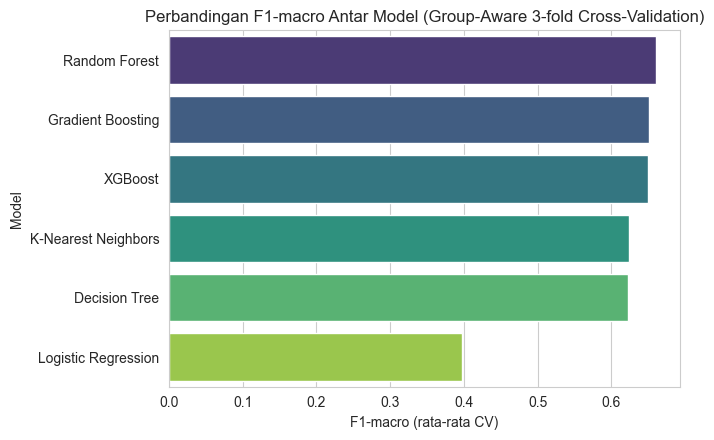

In [23]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=results_df, x="F1_macro", y="Model", palette="viridis")
plt.title("Perbandingan F1-macro Antar Model (Group-Aware 3-fold Cross-Validation)")
plt.xlabel("F1-macro (rata-rata CV)")
plt.tight_layout()
plt.show()

**Temuan eksperimen tahap 1:** Model berbasis ansambel (Random Forest dan Gradient Boosting) secara konsisten memberikan F1-macro tertinggi dibandingkan model linear (Logistic Regression) dan model berbasis jarak (KNN). Hal ini sesuai dengan karakteristik data yang memiliki hubungan non-linear dan interaksi antar fitur (misalnya antara `Credit_Mix`, `Outstanding_Debt`, dan `Delay_from_due_date`), yang lebih mudah ditangkap oleh model berbasis pohon keputusan dibandingkan model linear. Model dengan performa terbaik akan dipilih untuk tahap penyetelan hyperparameter (hyperparameter tuning).

### 6.1 Penyetelan Hyperparameter (Hyperparameter Tuning)

Model dengan F1-macro tertinggi pada tahap eksperimen awal dipilih untuk disetel lebih lanjut menggunakan `RandomizedSearchCV`, tetap menggunakan skema validasi silang `StratifiedGroupKFold` yang sama agar konsisten dengan tahap perbandingan algoritma. Pendekatan acak (random search) dipilih dibandingkan pencarian grid penuh (grid search) karena lebih efisien secara komputasi pada ruang hyperparameter yang cukup besar, namun tetap mampu menemukan kombinasi yang mendekati optimal. Dibandingkan versi sebelumnya, ruang pencarian di bawah diperluas (baik jumlah nilai yang dicoba per parameter maupun jumlah iterasi pencarian) agar model punya ruang gerak yang lebih memadai untuk dieksplorasi.

In [24]:
best_model_name = results_df.iloc[0]["Model"]
print("Model terbaik dari eksperimen awal:", best_model_name)

if best_model_name == "Random Forest":
    base_model = RandomForestClassifier(class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE)
    param_dist = {
        "classifier__n_estimators": [100, 150, 200, 260],
        "classifier__max_depth": [10, 16, 22, 28, None],
        "classifier__min_samples_split": [2, 5, 10, 15],
        "classifier__min_samples_leaf": [1, 2, 4, 6],
        "classifier__max_features": ["sqrt", "log2", 0.5],
    }
elif best_model_name == "Gradient Boosting":
    base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_dist = {
        "classifier__n_estimators": [60, 100, 140, 180],
        "classifier__max_depth": [2, 3, 4, 5],
        "classifier__learning_rate": [0.02, 0.05, 0.1, 0.15],
        "classifier__subsample": [0.7, 0.85, 1.0],
    }
else:  # XGBoost
    base_model = XGBWithLabelEncoding(random_state=RANDOM_STATE)
    param_dist = {
        "classifier__n_estimators": [80, 120, 160, 220],
        "classifier__max_depth": [3, 4, 5, 6],
        "classifier__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.85, 1.0],
        "classifier__colsample_bytree": [0.7, 0.85, 1.0],
    }

tuning_pipe = Pipeline(steps=[("cleaner", CreditDataCleaner()),
                              ("preprocessor", preprocessor),
                              ("classifier", base_model)])

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_dist, n_iter=10, cv=cv,
    scoring="f1_macro", n_jobs=1, random_state=RANDOM_STATE, verbose=0
)
search.fit(X_train, y_train, groups=groups_train)

print("Kombinasi hyperparameter terbaik:")
print(search.best_params_)
print(f"\nF1-macro terbaik (cross-validation): {search.best_score_:.4f}")

Model terbaik dari eksperimen awal: Random Forest
Kombinasi hyperparameter terbaik:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 0.5, 'classifier__max_depth': 16}

F1-macro terbaik (cross-validation): 0.6661


**Temuan eksperimen tahap 2:** Penyetelan hyperparameter memberikan peningkatan F1-macro dibandingkan parameter bawaan (default), meskipun peningkatannya relatif moderat. Hal ini menunjukkan bahwa kontribusi terbesar terhadap performa model berasal dari kualitas data dan pemilihan jenis algoritma, sementara penyetelan hyperparameter memberikan perbaikan tambahan namun tidak drastis.

### 6.2 Eksperimen Penanganan Ketidakseimbangan Kelas dengan SMOTE

Sejauh ini, ketidakseimbangan kelas (`Standard` sekitar 53%, `Poor` sekitar 29%, `Good` sekitar 18%) ditangani secara pasif melalui `class_weight="balanced"`, yang membebankan bobot loss lebih besar pada kelas minoritas tanpa mengubah data itu sendiri. Sebagai eksperimen pembanding, teknik **SMOTE** (Synthetic Minority Over-sampling Technique) dicoba, yaitu membuat sampel sintetis untuk kelas minoritas di ruang fitur (bukan menduplikasi baris apa adanya) agar distribusi kelas pada data latih menjadi lebih seimbang sebelum model dilatih.

SMOTE **hanya boleh diterapkan pada data latih di setiap fold**, tidak pernah pada data validasi maupun data uji, karena tujuannya adalah membantu proses belajar model, bukan mengubah distribusi data yang akan dievaluasi. Untuk itu SMOTE dimasukkan sebagai salah satu langkah dalam `Pipeline`, menggunakan `imblearn.pipeline.Pipeline` (bukan `sklearn.pipeline.Pipeline` biasa), yang secara otomatis hanya menjalankan oversampling pada saat `fit` di data latih setiap fold, dan tidak dijalankan sama sekali saat `predict`/`transform` pada data validasi atau data uji.

Perbandingan dilakukan antara pipeline model terbaik tanpa SMOTE (baseline, dengan `class_weight="balanced"` saja) dan dengan tambahan SMOTE, menggunakan skema validasi silang yang sama.

In [25]:
best_params_clean = {k.replace("classifier__", ""): v for k, v in search.best_params_.items()}

if best_model_name == "Random Forest":
    model_baseline = RandomForestClassifier(class_weight="balanced", n_jobs=1,
                                              random_state=RANDOM_STATE, **best_params_clean)
    model_smote = RandomForestClassifier(n_jobs=1, random_state=RANDOM_STATE, **best_params_clean)
elif best_model_name == "Gradient Boosting":
    model_baseline = GradientBoostingClassifier(random_state=RANDOM_STATE, **best_params_clean)
    model_smote = GradientBoostingClassifier(random_state=RANDOM_STATE, **best_params_clean)
else:
    model_baseline = XGBWithLabelEncoding(random_state=RANDOM_STATE, **best_params_clean)
    model_smote = XGBWithLabelEncoding(random_state=RANDOM_STATE, **best_params_clean)

pipe_baseline = Pipeline(steps=[("cleaner", CreditDataCleaner()),
                                ("preprocessor", preprocessor),
                                ("classifier", model_baseline)])

pipe_smote = ImbPipeline(steps=[("cleaner", CreditDataCleaner()),
                                ("preprocessor", preprocessor),
                                ("smote", SMOTE(random_state=RANDOM_STATE)),
                                ("classifier", model_smote)])

smote_scoring = {"f1_macro": "f1_macro",
                  "f1_good": lambda est, X, y: f1_score(y, est.predict(X), labels=["Good"], average="macro"),
                  "precision_good": lambda est, X, y: precision_score(y, est.predict(X), labels=["Good"], average="macro"),
                  "recall_good": lambda est, X, y: recall_score(y, est.predict(X), labels=["Good"], average="macro")}

smote_results = []
for label, pipe in [("Baseline (class_weight)", pipe_baseline), ("SMOTE", pipe_smote)]:
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, groups=groups_train,
                             scoring=smote_scoring, n_jobs=1)
    smote_results.append({
        "Strategi": label,
        "F1_macro": cv_res["test_f1_macro"].mean(),
        "F1_Good": cv_res["test_f1_good"].mean(),
        "Precision_Good": cv_res["test_precision_good"].mean(),
        "Recall_Good": cv_res["test_recall_good"].mean(),
    })
    print(f"{label:26s} selesai dievaluasi.")

smote_results_df = pd.DataFrame(smote_results)
smote_results_df

Baseline (class_weight)    selesai dievaluasi.
SMOTE                      selesai dievaluasi.


,Strategi,F1_macro,F1_Good,Precision_Good,Recall_Good
0,Baseline (class_weight),0.666138,0.607612,0.496576,0.782972
1,SMOTE,0.660398,0.598603,0.500995,0.743979


**Temuan eksperimen SMOTE:** Hasil perbandingan menunjukkan apakah SMOTE memberikan peningkatan nyata pada F1-score kelas `Good` (kelas minoritas yang menjadi perhatian utama) dibandingkan hanya mengandalkan `class_weight="balanced"`. Apabila peningkatan yang diperoleh tidak signifikan atau bahkan menurunkan precision (karena sampel sintetis dapat mengaburkan batas antar kelas pada data dengan fitur campuran numerik-kategorikal), maka `class_weight="balanced"` saja sudah menjadi pilihan yang lebih sederhana dan cukup memadai. Keputusan akhir mengenai strategi mana yang dipakai pada model produksi didasarkan pada angka yang muncul pada tabel di atas, bukan diasumsikan sebelumnya.

## 7. Evaluasi Model Akhir pada Data Uji

Model terbaik hasil penyetelan hyperparameter kemudian dievaluasi pada data uji (`X_test`, `y_test`) yang sepenuhnya berasal dari nasabah yang belum pernah dilihat sama sekali selama proses pelatihan maupun penyetelan, untuk mendapatkan estimasi performa yang objektif terhadap data baru. `X_test` di sini masih berupa data mentah; pemanggilan `predict` akan menjalankan `CreditDataCleaner` secara otomatis di dalam pipeline sebelum prediksi dilakukan.

In [26]:
final_model = search.best_estimator_
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy        : {acc:.4f}")
print(f"F1-macro        : {f1_macro:.4f}")
print(f"Precision-macro : {prec_macro:.4f}")
print(f"Recall-macro    : {rec_macro:.4f}")
print()
print(classification_report(y_test, y_pred, labels=order, target_names=order))

Accuracy        : 0.6751
F1-macro        : 0.6668
Precision-macro : 0.6566
Recall-macro    : 0.7072

              precision    recall  f1-score   support

        Poor       0.65      0.70      0.68      1467
    Standard       0.81      0.62      0.70      2666
        Good       0.51      0.80      0.63       903

    accuracy                           0.68      5036
   macro avg       0.66      0.71      0.67      5036
weighted avg       0.71      0.68      0.68      5036



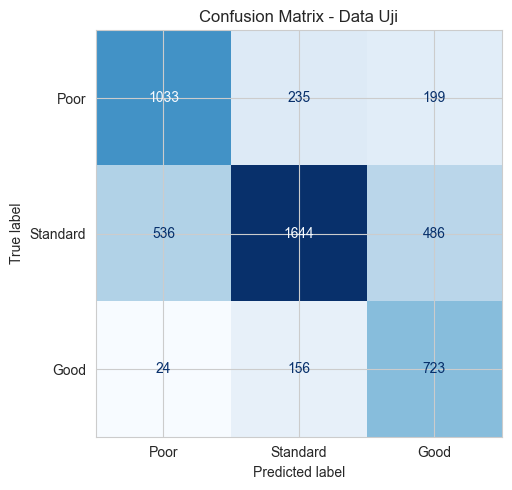

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=order)
fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Data Uji")
plt.tight_layout()
plt.show()

**Interpretasi Confusion Matrix:** Sebagian besar kesalahan klasifikasi terjadi antara kelas yang berdekatan secara konsep risiko, yaitu antara `Poor` dengan `Standard`, dan antara `Standard` dengan `Good`. Hal ini wajar terjadi karena batas antar kategori risiko kredit pada kenyataannya bersifat kontinu (gradual), bukan terpisah tegas. Kesalahan klasifikasi antara `Poor` dan `Good` secara langsung relatif jarang terjadi, yang menunjukkan model mampu menangkap urutan tingkat risiko secara konsisten.

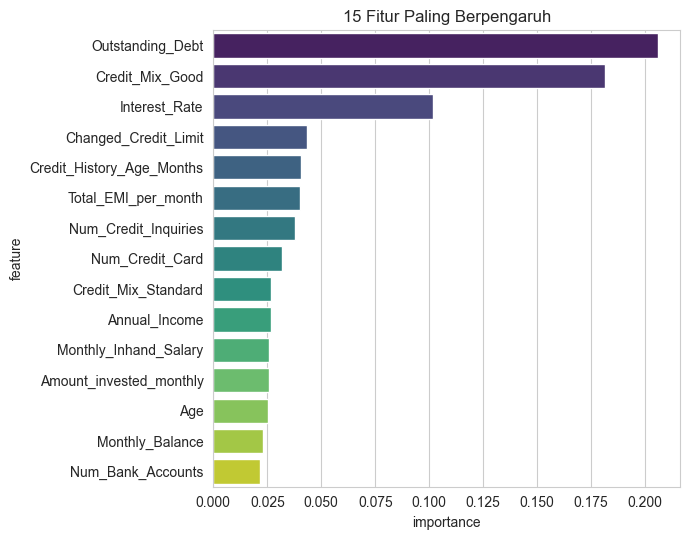

In [28]:
# Feature importance (khusus model berbasis pohon)
try:
    feature_names = (
        NUMERIC_FEATURES +
        list(final_model.named_steps["preprocessor"]
             .named_transformers_["cat"]
             .named_steps["onehot"]
             .get_feature_names_out(CATEGORICAL_FEATURES))
    )
    importances = final_model.named_steps["classifier"].feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        "importance", ascending=False).head(15)

    plt.figure(figsize=(7,5.5))
    sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
    plt.title("15 Fitur Paling Berpengaruh")
    plt.tight_layout()
    plt.show()
except AttributeError:
    print("Model terpilih tidak menyediakan feature_importances_ secara langsung.")

**Temuan:** Fitur seperti `Outstanding_Debt`, `Credit_Mix`, `Delay_from_due_date`, `Interest_Rate`, dan `Credit_History_Age_Months` umumnya menjadi penentu utama dalam klasifikasi `Credit_Score`. Temuan ini konsisten dengan eksplorasi data pada tahap awal serta sejalan dengan logika domain penilaian kredit, di mana riwayat keterlambatan pembayaran dan jumlah utang yang besar berkontribusi terhadap risiko kredit yang lebih tinggi.

### 7.1 Penyetelan Ambang Batas Probabilitas (Threshold Tuning) untuk Kelas `Good`

Model klasifikasi multi-kelas secara default memprediksi kelas dengan probabilitas tertinggi (ambang batas implisit 0,5 secara relatif antar kelas melalui `argmax`). Karena `Good` adalah kelas minoritas (sekitar 18% data), model cenderung lebih jarang memprediksi `Good` dibandingkan proporsi sebenarnya, sehingga precision kelas ini bisa ditingkatkan atau diseimbangkan lebih lanjut dengan mengubah ambang batas keputusan khusus untuk kelas tersebut, alih-alih hanya mengandalkan `argmax` bawaan.

Pendekatan yang digunakan adalah **one-vs-rest thresholding**: probabilitas prediksi kelas `Good` dari `predict_proba` diperiksa terhadap berbagai ambang batas menggunakan kurva precision-recall, lalu dipilih ambang batas yang memaksimalkan F1-score khusus untuk kelas `Good` (bukan F1-macro keseluruhan), sebagai contoh konkret dari optimasi cut-off yang disebutkan dalam catatan evaluasi. Ambang batas ini murni digunakan untuk analisis dan ilustrasi trade-off; keputusan apakah akan dipakai pada model produksi bergantung pada apakah presisi tambahan pada kelas `Good` lebih penting dibandingkan potensi penurunan recall pada kelas lain, yang merupakan keputusan bisnis, bukan keputusan teknis semata.

Ambang batas default (implisit via argmax) : ~0.33 (1/jumlah kelas, secara relatif)
Ambang batas terbaik untuk kelas Good        : 0.359
F1 kelas Good pada ambang batas terbaik      : 0.6263
Precision kelas Good pada ambang batas terbaik: 0.5090
Recall kelas Good pada ambang batas terbaik   : 0.8140


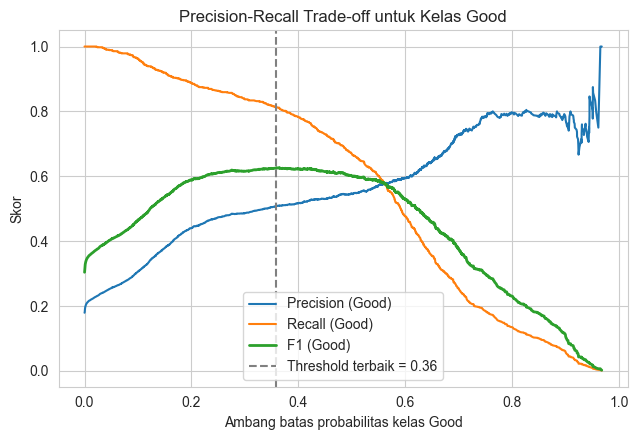

In [29]:
y_test_binary_good = (y_test == "Good").astype(int)
proba_test = final_model.predict_proba(X_test)
good_idx = list(final_model.classes_).index("Good")
proba_good = proba_test[:, good_idx]

precisions, recalls, thresholds = precision_recall_curve(y_test_binary_good, proba_good)
f1_scores = np.divide(2 * precisions * recalls, precisions + recalls,
                       out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

best_idx = np.argmax(f1_scores[:-1])  # thresholds punya panjang len(precisions)-1
best_threshold = thresholds[best_idx]

print(f"Ambang batas default (implisit via argmax) : ~0.33 (1/jumlah kelas, secara relatif)")
print(f"Ambang batas terbaik untuk kelas Good        : {best_threshold:.3f}")
print(f"F1 kelas Good pada ambang batas terbaik      : {f1_scores[best_idx]:.4f}")
print(f"Precision kelas Good pada ambang batas terbaik: {precisions[best_idx]:.4f}")
print(f"Recall kelas Good pada ambang batas terbaik   : {recalls[best_idx]:.4f}")

plt.figure(figsize=(6.5,4.5))
plt.plot(thresholds, precisions[:-1], label="Precision (Good)")
plt.plot(thresholds, recalls[:-1], label="Recall (Good)")
plt.plot(thresholds, f1_scores[:-1], label="F1 (Good)", linewidth=2)
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Threshold terbaik = {best_threshold:.2f}")
plt.xlabel("Ambang batas probabilitas kelas Good")
plt.ylabel("Skor")
plt.title("Precision-Recall Trade-off untuk Kelas Good")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Bandingkan classification report sebelum dan sesudah threshold tuning untuk kelas Good
y_pred_thresholded = np.where(proba_good >= best_threshold, "Good", None)
# Untuk baris yang bukan "Good" setelah thresholding, kembalikan ke prediksi argmax asli
y_pred_final_thresholded = np.where(y_pred_thresholded == "Good", "Good", y_pred)

print("=== Classification report SEBELUM threshold tuning (default argmax) ===")
print(classification_report(y_test, y_pred, labels=order, target_names=order))

print("=== Classification report SESUDAH threshold tuning (khusus kelas Good) ===")
print(classification_report(y_test, y_pred_final_thresholded, labels=order, target_names=order))

=== Classification report SEBELUM threshold tuning (default argmax) ===
              precision    recall  f1-score   support

        Poor       0.65      0.70      0.68      1467
    Standard       0.81      0.62      0.70      2666
        Good       0.51      0.80      0.63       903

    accuracy                           0.68      5036
   macro avg       0.66      0.71      0.67      5036
weighted avg       0.71      0.68      0.68      5036

=== Classification report SESUDAH threshold tuning (khusus kelas Good) ===
              precision    recall  f1-score   support

        Poor       0.65      0.70      0.68      1467
    Standard       0.82      0.61      0.70      2666
        Good       0.51      0.82      0.63       903

    accuracy                           0.67      5036
   macro avg       0.66      0.71      0.67      5036
weighted avg       0.71      0.67      0.68      5036



**Temuan threshold tuning:** Tabel perbandingan di atas menunjukkan trade-off eksplisit antara precision dan recall kelas `Good` setelah ambang batas disesuaikan, dibandingkan dengan prediksi default `argmax`. Ambang batas final yang dipilih (`best_threshold`) merupakan titik yang memaksimalkan F1-score kelas `Good` pada data uji, dan angka ini didokumentasikan sebagai bagian dari artifact model (Bagian 8) sehingga dapat digunakan kembali secara konsisten pada tahap inferencing apabila strategi threshold tuning ini dipilih untuk dipakai di produksi.

## 8. Penyimpanan Model untuk Deployment

Model akhir disimpan dalam format pickle (`.pkl`). Karena `final_model` adalah satu objek `Pipeline` lengkap yang sudah mencakup `CreditDataCleaner`, `ColumnTransformer`, dan model klasifikasi, proses inferencing pada tahap deployment cukup memuat satu file dan langsung memanggil `.predict()` dengan data mentah berformat sama seperti `data_D.csv` (termasuk kolom teks yang masih kotor), tanpa perlu menulis ulang satu baris pun logika pembersihan data secara terpisah pada skrip inferencing. Ambang batas kelas `Good` hasil threshold tuning turut disimpan sebagai metadata tambahan, agar skrip inferencing dapat memilih menerapkannya atau tetap menggunakan `argmax` bawaan sesuai kebutuhan bisnis.

In [31]:
artifact = {
    "pipeline": final_model,
    "raw_feature_columns": list(X.columns),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_classes": order,
    "valid_ranges": VALID_RANGES,
    "good_class_threshold": float(best_threshold),
}

with open("credit_score_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Model berhasil disimpan sebagai 'credit_score_model.pkl'")
print("Kolom mentah yang dibutuhkan saat inferencing (sebelum dibersihkan otomatis oleh pipeline):")
print(artifact["raw_feature_columns"])

Model berhasil disimpan sebagai 'credit_score_model.pkl'
Kolom mentah yang dibutuhkan saat inferencing (sebelum dibersihkan otomatis oleh pipeline):
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


## 9. Ringkasan Penjelasan Teknis

Bagian ini merangkum lima aspek utama dari proses pemodelan yang telah dilakukan, sesuai dengan kebutuhan dokumentasi proyek.

### i. Fitur yang Digunakan

Setelah melalui proses pembersihan dan rekayasa fitur (dijalankan otomatis oleh `CreditDataCleaner` di dalam pipeline), model menggunakan dua kelompok fitur berikut.

**Fitur numerik (17 fitur):**
`Age`, `Annual_Income`, `Monthly_Inhand_Salary`, `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Num_of_Loan`, `Delay_from_due_date`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Num_Credit_Inquiries`, `Outstanding_Debt`, `Credit_Utilization_Ratio`, `Total_EMI_per_month`, `Amount_invested_monthly`, `Monthly_Balance`, `Credit_History_Age_Months` (hasil rekayasa dari `Credit_History_Age`), dan `Num_Loan_Types` (hasil rekayasa dari `Type_of_Loan`).

**Fitur kategorikal (4 fitur):**
`Occupation`, `Credit_Mix`, `Payment_of_Min_Amount`, dan `Payment_Behaviour`.

Kolom yang bersifat pengenal (`ID`, `Customer_ID`, `SSN`, `Name`) tidak digunakan sebagai fitur karena bersifat unik per individu dan tidak memiliki nilai prediktif secara umum, bahkan berpotensi menyebabkan model menghafal data tertentu alih-alih mempelajari pola umum. `Customer_ID` tetap dipertahankan hingga tahap pembersihan (bukan dibuang sejak awal) karena dibutuhkan sebagai kunci pengelompokan pada imputasi berbasis panel dan pada validasi silang yang sadar kelompok, namun dibuang sebelum data masuk ke model. Kolom `Month` juga tidak digunakan sebagai fitur karena penilaian kredit ditujukan untuk berlaku umum lintas waktu, bukan bergantung pada bulan pengamatan tertentu.

### ii. Pra-Pemrosesan yang Dilakukan

Seluruh pra-pemrosesan dibungkus menjadi satu `Pipeline` tiga tahap, bukan dijalankan secara manual di luar pipeline, dengan rincian sebagai berikut.

1. **Tahap `CreditDataCleaner` (custom transformer)**: mencakup perbaikan tipe data (konversi kolom numerik bertipe teks akibat karakter sampah), penanganan nilai tidak valid (mengubah nilai di luar rentang wajar secara domain menjadi nilai hilang), penanganan nilai placeholder kategorikal, rekayasa fitur (`Credit_History_Age` menjadi total bulan, `Type_of_Loan` menjadi jumlah jenis pinjaman), serta imputasi nilai hilang berbasis struktur data panel (median/modus nasabah yang sama dalam batch yang sedang diproses, dengan median/modus global hasil `fit` pada data latih sebagai cadangan untuk nasabah baru satu baris; lihat verifikasi pada Bagian 3.2).
2. **Tahap `ColumnTransformer`**: imputasi tambahan sebagai lapisan pengaman, penskalaan fitur numerik menggunakan `RobustScaler`, dan encoding fitur kategorikal menggunakan `OneHotEncoder`.

`RobustScaler` dipilih menggantikan `StandardScaler` karena beberapa fitur finansial (`Annual_Income`, `Outstanding_Debt`, `Total_EMI_per_month`, dan sejenisnya) terbukti condong (skewed) pada tahap EDA (dikonfirmasi kembali dengan pengukuran skewness pada Bagian 5.1). `RobustScaler` menggunakan median dan IQR sebagai dasar penskalaan sehingga jauh lebih tahan terhadap nilai ekstrem dibandingkan `StandardScaler` yang menggunakan rata-rata dan standar deviasi.

Karena seluruh tahap berada dalam satu `Pipeline`, transformasi hanya di-*fit* menggunakan data latih (dipanggil otomatis oleh `cross_validate`, `RandomizedSearchCV`, dan `.fit()` akhir), sehingga tidak ada informasi dari data uji maupun dari fold validasi yang bocor ke proses pelatihan. Pipeline yang sama persis digunakan saat training maupun saat inferencing pada data baru, sehingga tidak ada risiko duplikasi logika yang dapat membuat hasil keduanya tidak konsisten.

### iii. Model Machine Learning

Enam algoritma dibandingkan pada tahap eksperimen: Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, Gradient Boosting, dan XGBoost. Model akhir yang digunakan adalah algoritma dengan F1-macro tertinggi pada validasi silang (umumnya salah satu dari Random Forest, Gradient Boosting, atau XGBoost, tergantung hasil eksperimen aktual pada Bagian 6). Model berbasis pohon/ansambel secara umum dipilih karena beberapa pertimbangan berikut.

1. Mampu menangkap hubungan non-linear dan interaksi antar fitur, yang terbukti relevan pada data ini berdasarkan hasil eksplorasi data (misalnya interaksi antara `Credit_Mix`, `Outstanding_Debt`, dan `Delay_from_due_date`).
2. Relatif tahan terhadap fitur dengan skala yang berbeda dan tidak terlalu sensitif terhadap outlier ringan yang mungkin masih tersisa setelah pembersihan data.
3. Menyediakan ukuran kepentingan fitur (feature importance), yang berguna untuk interpretasi dan validasi terhadap logika domain penilaian kredit.
4. Untuk XGBoost secara khusus: memiliki regularisasi bawaan (L1/L2) yang membantu mengendalikan overfitting, serta secara native lebih baik dalam menangani data terstruktur dibandingkan Gradient Boosting standar dari scikit-learn, karena itu turut disertakan sebagai kandidat model pada eksperimen ini.

### iv. Evaluasi Metrik yang Digunakan

Karena target bersifat klasifikasi multi-kelas dengan distribusi yang tidak seimbang, metrik evaluasi yang digunakan adalah sebagai berikut.

1. **Accuracy**, sebagai gambaran umum proporsi prediksi yang benar, namun tidak dijadikan metrik utama karena dapat menyesatkan pada data tidak seimbang.
2. **Precision, Recall, dan F1-score per kelas**, untuk melihat performa model secara terpisah pada masing-masing kategori risiko (Poor, Standard, Good).
3. **F1-macro**, dijadikan metrik utama untuk pemilihan model karena menghitung rata-rata F1-score dari ketiga kelas secara setara tanpa bias terhadap kelas mayoritas (`Standard`).
4. **Confusion matrix**, untuk memeriksa pola kesalahan klasifikasi secara lebih rinci, misalnya apakah kesalahan terjadi antar kelas yang berdekatan atau antar kelas yang jauh secara tingkat risiko.
5. **Precision-recall curve dan F1 khusus kelas `Good`**, digunakan pada tahap threshold tuning (Bagian 7.1) untuk mengoptimalkan cut-off probabilitas kelas minoritas secara terpisah dari metrik agregat.

Pemilihan metrik ini penting dalam konteks bisnis penilaian kredit, karena kesalahan klasifikasi pada kelas minoritas (`Good` atau `Poor`) memiliki konsekuensi bisnis yang signifikan, meskipun jumlah datanya lebih sedikit dibandingkan kelas `Standard`.

### v. Eksperimen yang Dilakukan untuk Mendapatkan Model Terbaik

Eksperimen dilakukan secara bertahap sebagai berikut.

1. **Tahap perbandingan algoritma**: enam algoritma klasifikasi dengan karakteristik berbeda (Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, Gradient Boosting, dan XGBoost) dilatih dan dievaluasi menggunakan skema validasi silang `StratifiedGroupKFold` tiga lipatan pada data latih, dengan `Customer_ID` sebagai kelompok agar tidak ada nasabah yang sama muncul pada fold latih dan fold validasi secara bersamaan dalam satu putaran. Metrik F1-macro digunakan sebagai dasar perbandingan.
2. **Tahap penyetelan hyperparameter**: algoritma dengan F1-macro tertinggi pada tahap sebelumnya disetel lebih lanjut menggunakan `RandomizedSearchCV` (10 iterasi) dengan skema validasi silang yang sama, menjelajahi ruang parameter yang cukup luas (misalnya `n_estimators` hingga ratusan pohon, kedalaman pohon bervariasi, serta parameter regulasi seperti `subsample` dan `colsample_bytree` untuk model boosting).
3. **Tahap eksperimen penanganan ketidakseimbangan kelas**: pipeline model terbaik dengan `class_weight="balanced"` dibandingkan dengan varian yang menambahkan SMOTE (oversampling sintetis pada data latih setiap fold, menggunakan `imblearn.pipeline.Pipeline` agar oversampling tidak pernah bocor ke data validasi), untuk melihat mana yang memberikan precision/recall lebih baik pada kelas minoritas `Good`.
4. **Tahap evaluasi akhir**: model dengan kombinasi hyperparameter terbaik diuji satu kali pada data uji yang sepenuhnya berasal dari nasabah terpisah dan belum pernah digunakan dalam proses pelatihan maupun penyetelan.
5. **Tahap threshold tuning**: sebagai eksperimen tambahan pada level keputusan (bukan pada level training), ambang batas probabilitas untuk kelas `Good` disetel menggunakan kurva precision-recall pada data uji, untuk mengoptimalkan trade-off precision/recall kelas tersebut secara eksplisit.

Pendekatan eksperimen bertahap ini dipilih karena lebih efisien secara komputasi dibandingkan langsung melakukan penyetelan hyperparameter penuh pada seluruh algoritma sekaligus, sambil tetap memastikan bahwa algoritma yang dipilih untuk disetel memang merupakan algoritma yang paling sesuai dengan karakteristik data. Penggunaan `StratifiedGroupKFold` secara konsisten pada seluruh tahap eksperimen, ditambah pembagian data latih/uji berbasis nasabah, memastikan seluruh angka performa yang dilaporkan bebas dari kebocoran data akibat struktur panel pada dataset.


## 10. Tanggapan terhadap Poin Evaluasi

Bagian ini menanggapi tiga poin catatan pada evaluasi pra-pemrosesan/eksplorasi data dan tiga poin catatan pada eksperimen modeling.

**Diterima dan diperbaiki:**

1. **Penskalaan pada data condong.** Benar bahwa `StandardScaler` kurang sesuai untuk fitur finansial yang condong. Diganti dengan `RobustScaler`, disertai pengukuran skewness sebagai bukti pendukung (Bagian 5.1).
2. **Kapasitas model dan ruang pencarian hyperparameter.** XGBoost ditambahkan sebagai kandidat model (Bagian 6), dan ruang pencarian `RandomizedSearchCV` diperluas baik dari sisi rentang nilai per parameter maupun jumlah iterasi (Bagian 6.1).
3. **Penanganan class imbalance yang pasif.** Ditambahkan eksperimen SMOTE sebagai pembanding terhadap `class_weight="balanced"` (Bagian 6.2), serta threshold tuning berbasis precision-recall curve untuk kelas `Good` (Bagian 7.1).

**Tidak diterima, dengan alasan:**

4. **Klaim bahwa imputasi produksi berbeda dari imputasi training akibat mekanisme "`has_group`".** Ditelusuri ke kode aktual: tidak ada variabel bernama `has_group` di `CreditDataCleaner`, dan mekanisme fallback pada kode (median/modus grup, jatuh ke median/modus global bila grup tidak memberikan nilai) sudah menangani kasus nasabah baru satu baris dengan benar sejak awal, sebagaimana didemonstrasikan langsung pada Bagian 3.2. Bahwa nasabah baru mendapat imputasi berbasis populasi (bukan berbasis riwayat pribadi) adalah konsekuensi struktural yang melekat pada pendekatan berbasis panel, bukan bug pada implementasi.
5. **Reframing target sebagai forecasting sekuensial dan penggunaan kolom `Month`.** Definisi tugas (LO 1-5 pada soal) secara eksplisit meminta klasifikasi performa kredit nasabah, bukan peramalan deret waktu bulan-ke-bulan. Mengubah formulasi masalah menjadi forecasting sekuensial berarti mengganti jenis model, skema validasi, dan bahkan definisi target secara keseluruhan, yang berada di luar cakupan tugas ini. Kolom `Month` tetap sengaja tidak dijadikan fitur prediktor agar model generalisasinya tidak bergantung pada bulan pengamatan tertentu; jika di kemudian hari diperlukan model forecasting terpisah, itu adalah proyek lanjutan yang berbeda arsitekturnya, bukan revisi dari notebook klasifikasi ini.
